<a href="https://colab.research.google.com/github/jeetb270/Stratify_2026_Dark_Matter/blob/main/stratify_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
# IMPORTING LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
# READING DATA

cand_sites = pd.read_csv("Data/candidate_sites.csv")
order_log = pd.read_csv("Data/order_log.csv")
pincode_den = pd.read_csv("Data/pincode_density.csv")
store_master = pd.read_csv("Data/store_master.csv")
data_dict = pd.read_csv("Data/data_dictionary.csv")

# Understand data format to clean the data

print("Candidate Sites:\n", cand_sites.head())
print("\nOrder Logs:\n", order_log.head())
print("\nPincode Density:\n", pincode_den.head())
print("\nStore Master:\n", store_master.head())
print("\nData Dictionary:\n", data_dict.head())

Candidate Sites:
   site_id  city  site_lat  site_lon  site_pincode  carpet_area_sqft  \
0   CS-01  Pune   18.5975    73.764        411057              2650   
1   CS-02  Pune   18.5760    73.770        411045              2400   
2   CS-03  Pune   18.4670    73.888        411048              2900   
3   CS-04  Pune   18.5090    73.813        411038              2200   
4   CS-05  Pune   18.5640    73.908        411014              2050   

   monthly_rent_inr  one_time_fitout_cost_inr  
0             82000                   1650000  
1             76000                   1480000  
2             64000                   1520000  
3             88000                   1390000  
4             79000                   1310000  

Order Logs:
      order_id      order_timestamp       city store_id  delivery_pincode  \
0  ORD0000001  2026-04-01 00:14:29       Pune   PUN-07            411057   
1  ORD0000002  2026-04-01 00:15:20       Pune   PUN-01            411058   
2  ORD0000003  2026-04-01

In [86]:
# CLEANING DATA

# Convert date and time columns to datetime objects
order_log['order_timestamp'] = pd.to_datetime(order_log['order_timestamp'])
store_master['go_live_date'] = pd.to_datetime(store_master['go_live_date'])

# Extract the month from the order timestamp for monthly fixed cost calculations later
order_log['order_month'] = order_log['order_timestamp'].dt.to_period('M')

# Create a breach flag: True if actual_delivery_min > promised_delivery_min
order_log['breach'] = order_log['actual_delivery_min'] > order_log['promised_delivery_min']

# Drop any potential duplicates in the order log
order_log = order_log.drop_duplicates(subset=['order_id'])

# Drop orders containing missing values
order_log = order_log.dropna(subset=['order_id', 'delivery_lat', 'delivery_lon', 'store_id', 'actual_delivery_min'])

print("Data cleaning completed.")
print(order_log[['order_id', 'order_timestamp', 'breach']].head())

Data cleaning completed.
     order_id     order_timestamp  breach
0  ORD0000001 2026-04-01 00:14:29   False
1  ORD0000002 2026-04-01 00:15:20   False
2  ORD0000003 2026-04-01 00:27:56   False
3  ORD0000004 2026-04-01 00:28:20   False
4  ORD0000005 2026-04-01 00:28:39   False


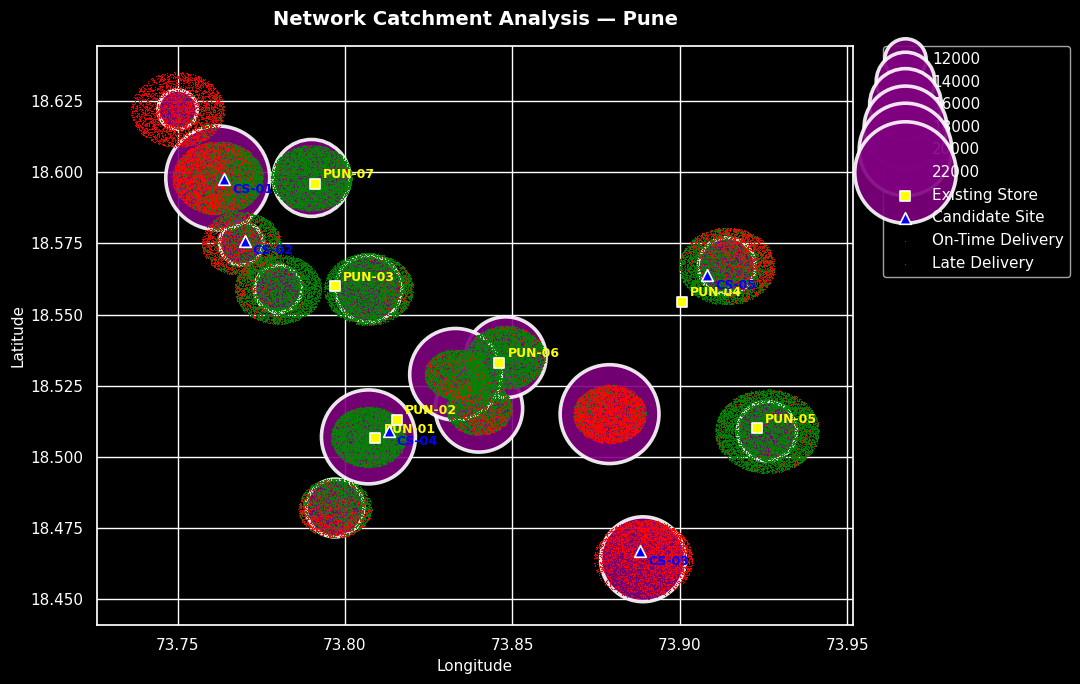

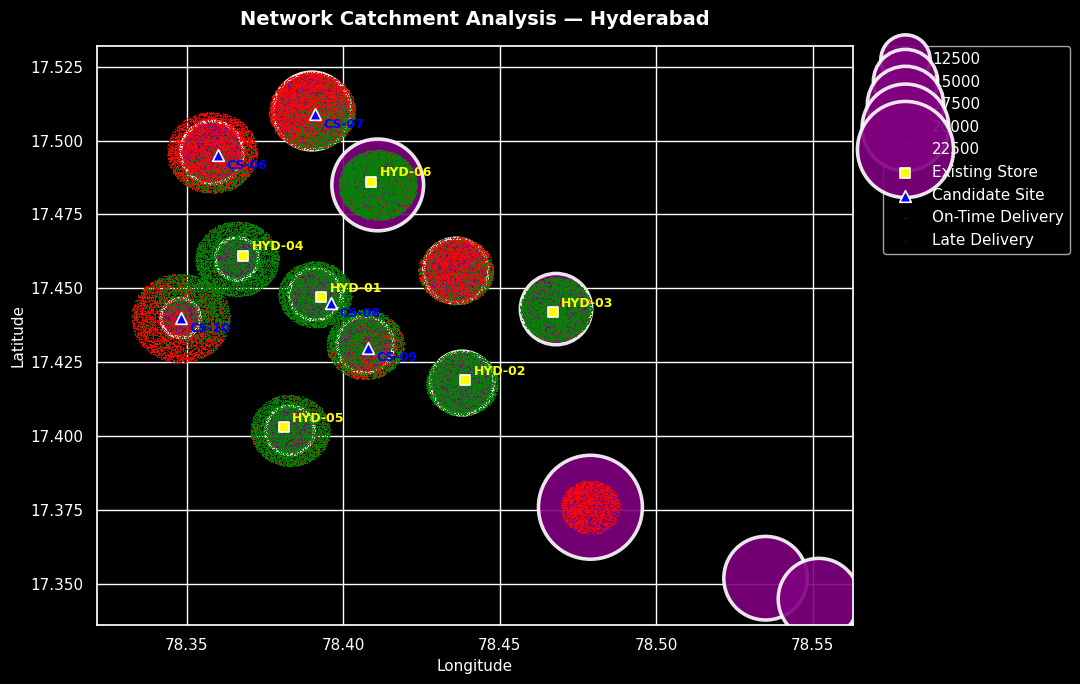

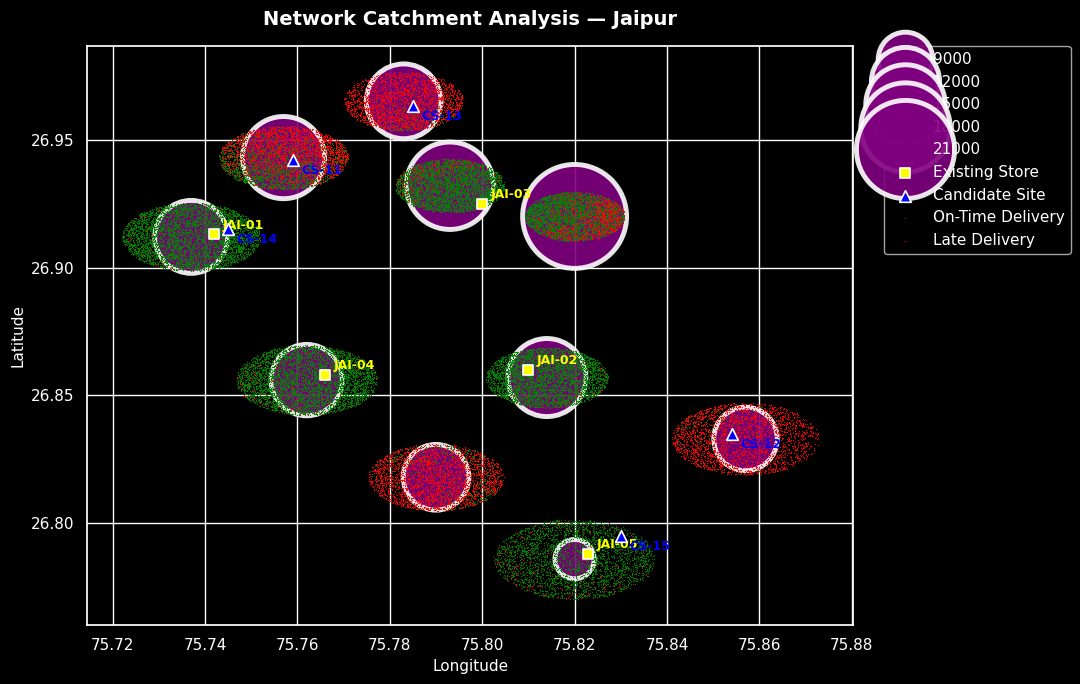

In [87]:
# CREATING A VISUAL

# Set the plot style
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')

# Cities in scope
cities = ['Pune', 'Hyderabad', 'Jaipur']

for city in cities:
    # Filter datasets by city
    city_pincodes = pincode_den[pincode_den['city'] == city]
    city_stores = store_master[store_master['city'] == city]
    city_candidates = cand_sites[cand_sites['city'] == city]
    city_orders = order_log[order_log['city'] == city]

    plt.figure(figsize=(11, 7))

    # 1. Pincode Centroids (Bubble size = Population Density)
    sns.scatterplot(
        data=city_pincodes,
        x='pincode_centroid_lon',
        y='pincode_centroid_lat',
        size='population_density_per_sqkm',
        sizes=(800, 5600),
        alpha=0.90,
        color='purple',
        legend='brief'
    )

    # 2. Existing Active Dark Stores
    plt.scatter(
        city_stores['store_lon'],
        city_stores['store_lat'],
        color='yellow',
        marker='s',        # Square marker
        s=60,
        edgecolor='white',
        linewidth=1.2,
        zorder=5,
        label='Existing Store'
    )

    # 3. Candidate Dark Store Sites
    plt.scatter(
        city_candidates['site_lon'],
        city_candidates['site_lat'],
        color='blue',
        marker='^',        # Triangle marker
        s=70,
        edgecolor='white',
        linewidth=1.2,
        zorder=5,
        label='Candidate Site'
    )

    on_time = city_orders[city_orders['actual_delivery_min'] <= city_orders['promised_delivery_min']]
    delayed = city_orders[city_orders['actual_delivery_min'] > city_orders['promised_delivery_min']]

    plt.scatter(
        on_time['delivery_lon'],
        on_time['delivery_lat'],
        s=0.75,
        color='green',
        edgecolor='white',
        linewidth=0.01,
        zorder=1,
        label='On-Time Delivery'
    )

    plt.scatter(
        delayed['delivery_lon'],
        delayed['delivery_lat'],
        s=0.75,
        color='red',
        edgecolor='white',
        linewidth=0.01,
        zorder=1,
        label='Late Delivery'
    )

    # Annotate store IDs
    for _, row in city_stores.iterrows():
        plt.annotate(
            row['store_id'],
            (row['store_lon'], row['store_lat']),
            fontsize=9, fontweight='bold', color='yellow',
            xytext=(6, 4), textcoords='offset points'
        )

    # Annotate candidate site IDs
    for _, row in city_candidates.iterrows():
        plt.annotate(
            row['site_id'],
            (row['site_lon'], row['site_lat']),
            fontsize=9, fontweight='bold', color='blue',
            xytext=(6, -10), textcoords='offset points'
        )

    # Styling and Labels
    plt.title(f'Network Catchment Analysis — {city}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Longitude', fontsize=11)
    plt.ylabel('Latitude', fontsize=11)

    # Place legend outside plot area
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()

    plt.show()

In [89]:
# KEY TASK 1:

cost_to_serve = pd.merge(order_log, store_master, on = ['store_id', 'city'], how = 'left')

cost_to_serve['no_of_orders'] = cost_to_serve.groupby(['store_id', 'order_month'])['order_id'].transform('count')

# Vectorized Distance Calculation
lat = cost_to_serve['delivery_lat'] - cost_to_serve['store_lat']
lon = cost_to_serve['delivery_lon'] - cost_to_serve['store_lon']
lat_mean = (cost_to_serve['delivery_lat'] + cost_to_serve['store_lat']) / 2.0

cost_to_serve['distance'] = np.sqrt(
    (lat * 111.0) ** 2 +
    (lon * 111.0 * np.cos(np.radians(lat_mean))) ** 2
)

# Vectorized Cost Allocation
breach_penalty = np.where(cost_to_serve['breach'] == True, 30.0, 0.0)

# Total monthly store overhead divided by orders fulfilled by that store in that month
fixed_cost_per_order = (
    cost_to_serve['monthly_rent_inr'] + cost_to_serve['monthly_fixed_cost_inr']
) / cost_to_serve['no_of_orders']

# Combine all components into final cost vector
cost_to_serve['cost'] = 30.0 + (7.0 * cost_to_serve['distance']) + breach_penalty + fixed_cost_per_order

print(cost_to_serve.head())

     order_id     order_timestamp       city store_id  delivery_pincode  \
0  ORD0000001 2026-04-01 00:14:29       Pune   PUN-07            411057   
1  ORD0000002 2026-04-01 00:15:20       Pune   PUN-01            411058   
2  ORD0000003 2026-04-01 00:27:56  Hyderabad   HYD-04            500032   
3  ORD0000004 2026-04-01 00:28:20       Pune   PUN-03            411021   
4  ORD0000005 2026-04-01 00:28:39  Hyderabad   HYD-06            500049   

   delivery_lat  delivery_lon  basket_value_inr  promised_delivery_min  \
0     18.594295     73.771084            528.93                     10   
1     18.478135     73.801242            308.24                     10   
2     17.431143     78.337979            357.72                     10   
3     18.553791     73.768771            574.25                     10   
4     17.501828     78.388093            250.99                     10   

   actual_delivery_min  ... breach  store_lat  store_lon  store_pincode  \
0                 2.81  ...  

In [91]:
# KEY TASK 2:

cost_to_serve['group'] = np.ceil(cost_to_serve['distance'] / 0.5)

# Aggregate total orders and breaches by store_id and group
grouped = cost_to_serve.groupby(['store_id', 'group'])['breach'].agg(
    total_orders='count',
    breach_count='sum'
).reset_index()

# Reindex/Fill missing groups per store to ensure unbroken distance steps
all_stores = grouped['store_id'].unique()
max_group = int(grouped['group'].dropna().max())
full_index = pd.MultiIndex.from_product([all_stores, range(1, max_group + 1)], names=['store_id', 'group'])

grouped = grouped.set_index(['store_id', 'group']).reindex(full_index, fill_value=0).reset_index()

# Sort and calculate cumulative totals
grouped = grouped.sort_values(['store_id', 'group'])
grouped['cum_orders'] = grouped.groupby('store_id')['total_orders'].cumsum()
grouped['cum_breaches'] = grouped.groupby('store_id')['breach_count'].cumsum()

# Calculate cumulative breach rate
grouped['cum_breach_rate'] = np.where(
    grouped['cum_orders'] > 0,
    grouped['cum_breaches'] / grouped['cum_orders'],
    0.0
)

# Filter for groups reaching >= 20% breach rate
breach_threshold_met = grouped[grouped['cum_breach_rate'] >= 0.2]

# Extract the FIRST group hitting threshold per store and calculate radius
first_breach_group = breach_threshold_met.groupby('store_id')['group'].first().reset_index()
first_breach_group['calculated_radius'] = first_breach_group['group'] * 0.5

# Merge using the unique temporary column name 'calculated_radius'
cost_to_serve = cost_to_serve.merge(
    first_breach_group[['store_id', 'calculated_radius']],
    on='store_id',
    how='left'
)

# Calculate dynamic fallback for stores that never hit 20% breach
max_group_per_store = cost_to_serve.groupby('store_id')['group'].transform('max')
fallback_radius = -1.0 * (0.5 * max_group_per_store)

# Assign directly to final 'service_radius' column
cost_to_serve['service_radius'] = cost_to_serve['calculated_radius'].fillna(fallback_radius)

# Clean up temporary working column
cost_to_serve.drop(columns=['calculated_radius'], inplace=True)

print(cost_to_serve.head())

     order_id     order_timestamp       city store_id  delivery_pincode  \
0  ORD0000001 2026-04-01 00:14:29       Pune   PUN-07            411057   
1  ORD0000002 2026-04-01 00:15:20       Pune   PUN-01            411058   
2  ORD0000003 2026-04-01 00:27:56  Hyderabad   HYD-04            500032   
3  ORD0000004 2026-04-01 00:28:20       Pune   PUN-03            411021   
4  ORD0000005 2026-04-01 00:28:39  Hyderabad   HYD-06            500049   

   delivery_lat  delivery_lon  basket_value_inr  promised_delivery_min  \
0     18.594295     73.771084            528.93                     10   
1     18.478135     73.801242            308.24                     10   
2     17.431143     78.337979            357.72                     10   
3     18.553791     73.768771            574.25                     10   
4     17.501828     78.388093            250.99                     10   

   actual_delivery_min  ... store_lon  store_pincode  monthly_rent_inr  \
0                 2.81  ...   

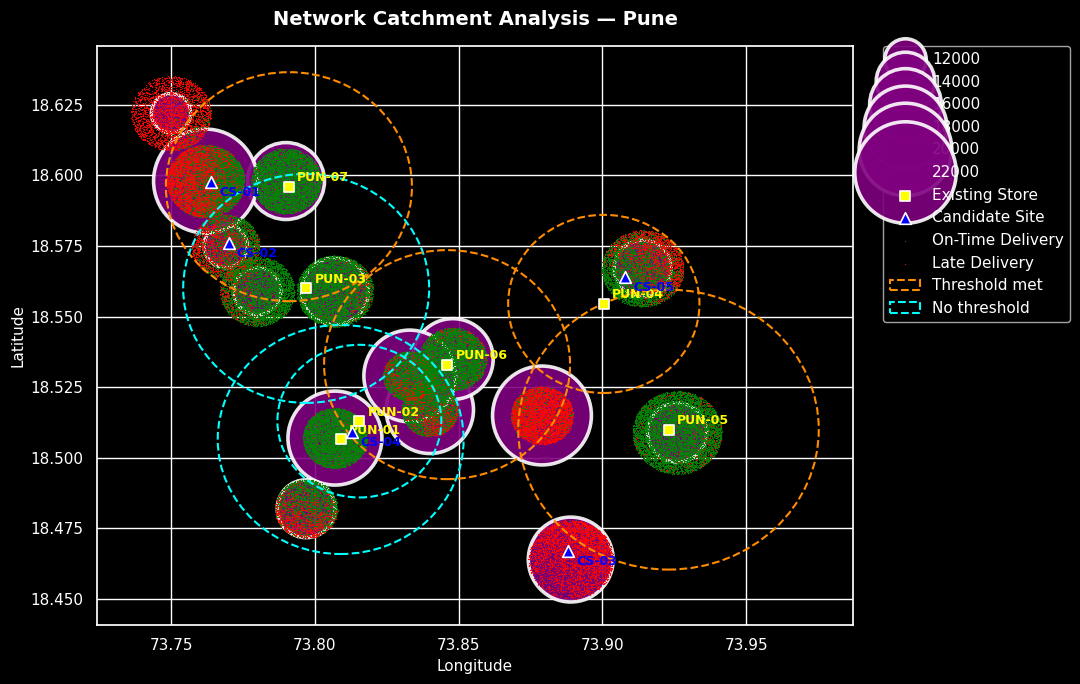

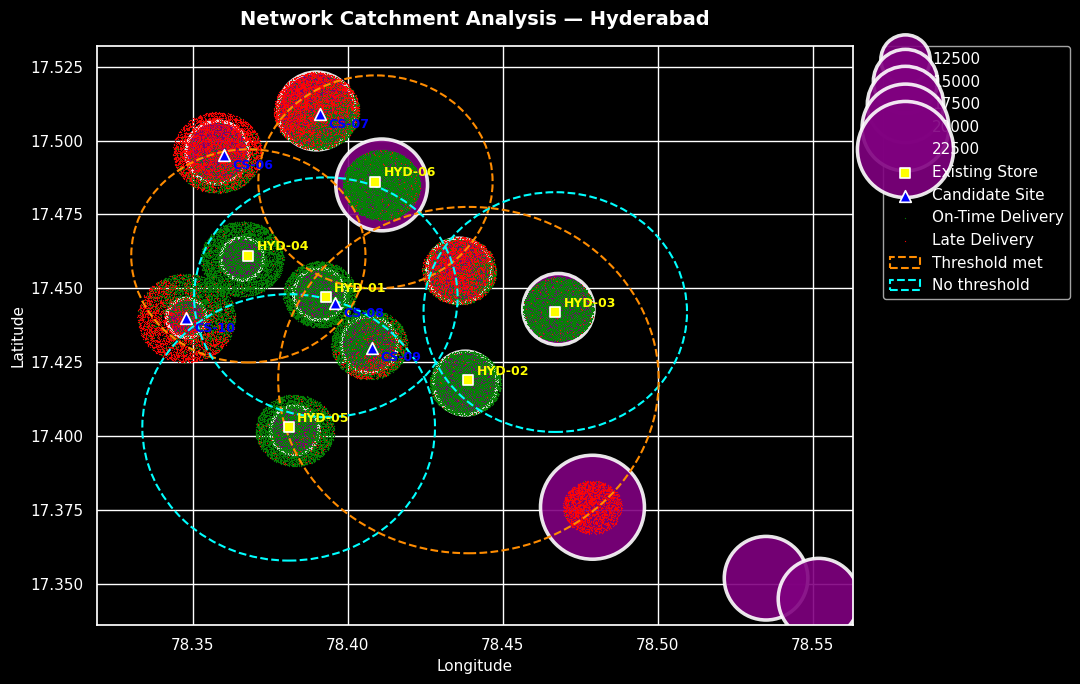

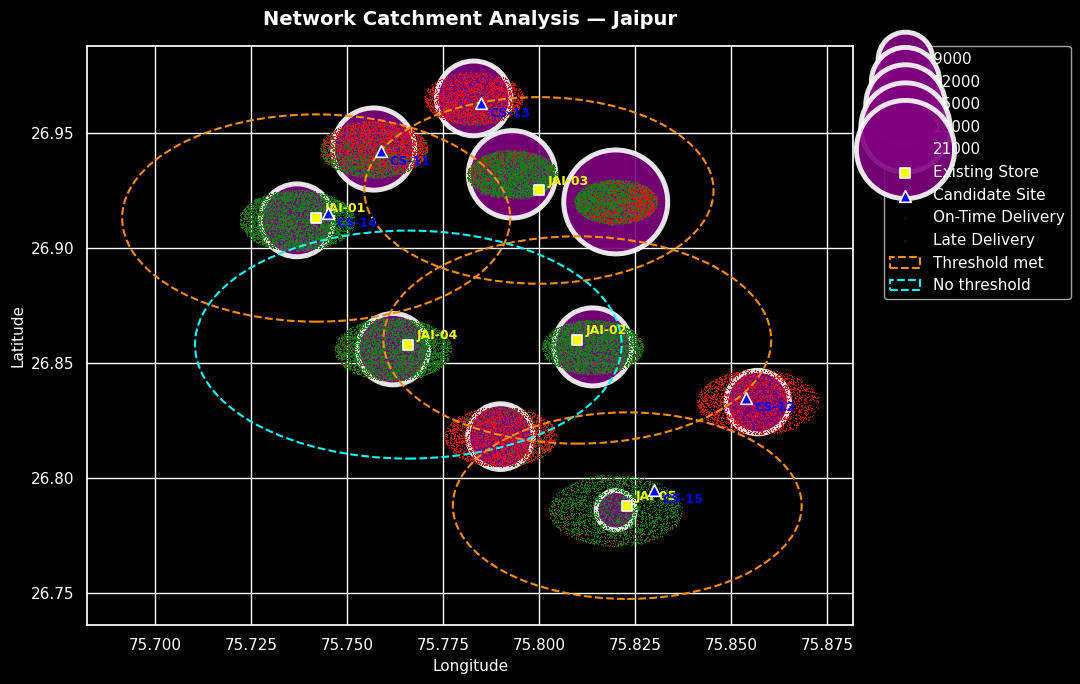

In [92]:
# VISUAL WITH SERVICE RADIUS

from matplotlib.patches import Ellipse

# Set the plot style
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')

# Cities in scope
cities = ['Pune', 'Hyderabad', 'Jaipur']

for city in cities:
    # Filter datasets by city
    city_pincodes = pincode_den[pincode_den['city'] == city]
    city_stores = store_master[store_master['city'] == city]
    city_candidates = cand_sites[cand_sites['city'] == city]
    city_orders = order_log[order_log['city'] == city]
    city_cts = cost_to_serve[cost_to_serve['city'] == city]

    plt.figure(figsize=(11, 7))

    # 1. Pincode Centroids (Bubble size = Population Density)
    sns.scatterplot(
        data=city_pincodes,
        x='pincode_centroid_lon',
        y='pincode_centroid_lat',
        size='population_density_per_sqkm',
        sizes=(800, 5600),
        alpha=0.90,
        color='purple',
        legend='brief'
    )

    # 2. Existing Active Dark Stores
    plt.scatter(
        city_stores['store_lon'],
        city_stores['store_lat'],
        color='yellow',
        marker='s',        # Square marker
        s=60,
        edgecolor='white',
        linewidth=1.2,
        zorder=5,
        label='Existing Store'
    )

    # 3. Candidate Dark Store Sites
    plt.scatter(
        city_candidates['site_lon'],
        city_candidates['site_lat'],
        color='blue',
        marker='^',        # Triangle marker
        s=70,
        edgecolor='white',
        linewidth=1.2,
        zorder=5,
        label='Candidate Site'
    )

    on_time = city_orders[city_orders['actual_delivery_min'] <= city_orders['promised_delivery_min']]
    delayed = city_orders[city_orders['actual_delivery_min'] > city_orders['promised_delivery_min']]

    plt.scatter(
        on_time['delivery_lon'],
        on_time['delivery_lat'],
        s=0.75,
        color='green',
        edgecolor='white',
        linewidth=0.01,
        zorder=1,
        label='On-Time Delivery'
    )

    plt.scatter(
        delayed['delivery_lon'],
        delayed['delivery_lat'],
        s=0.75,
        color='red',
        edgecolor='white',
        linewidth=0.01,
        zorder=1,
        label='Late Delivery'
    )

    # Extract just the unique stores and their radii to prevent duplicate drawing
    store_radii = city_cts[['store_id', 'store_lat', 'store_lon', 'service_radius']].drop_duplicates()

    # Get the current Axes object to add patches to
    ax = plt.gca()

    # Draw the catchment area for each unique store
    red = False
    blue = False
    for _, row in store_radii.iterrows():
        lat = row['store_lat']
        lon = row['store_lon']
        radius_km = row['service_radius']

        if radius_km > 0:
            # Reached threshold: Red
            r_km = radius_km
            color = 'darkorange'
            label = 'Threshold met' if not red else None
            red = True
        else:
            # Fallback (never reached 20%): Blue
            r_km = abs(radius_km)
            color = 'cyan'
            label = 'No threshold' if not blue else None
            blue = True

        # --- Radius Conversion Math ---

        # 1° latitude ≈ 111 km
        lat_radius_deg = r_km / 111.0

        # 1° longitude ≈ 111 * cos(latitude) km
        # np.cos() requires radians, so we convert the latitude first
        lon_radius_deg = r_km / (111.0 * np.cos(np.radians(lat)))

        # Create an Ellipse to represent the true circular area on a flat grid
        # width = x-axis diameter (longitude span)
        # height = y-axis diameter (latitude span)
        catchment_area = Ellipse(
            xy=(lon, lat),
            width=lon_radius_deg * 2,
            height=lat_radius_deg * 2,
            color=color,
            fill=False,
            linewidth=1.5,
            linestyle='--',
            label = label
        )

        # Add the patch to the plot
        ax.add_patch(catchment_area)

    # Annotate store IDs
    for _, row in city_stores.iterrows():
        plt.annotate(
            row['store_id'],
            (row['store_lon'], row['store_lat']),
            fontsize=9, fontweight='bold', color='yellow',
            xytext=(6, 4), textcoords='offset points'
        )

    # Annotate candidate site IDs
    for _, row in city_candidates.iterrows():
        plt.annotate(
            row['site_id'],
            (row['site_lon'], row['site_lat']),
            fontsize=9, fontweight='bold', color='blue',
            xytext=(6, -10), textcoords='offset points'
        )

    # Styling and Labels
    plt.title(f'Network Catchment Analysis — {city}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Longitude', fontsize=11)
    plt.ylabel('Latitude', fontsize=11)

    # Place legend outside plot area
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()

    plt.show()